## Dissipator with off-diagonal terms



The disppator can be divided to two parts:

for emission, 

$$
\begin{aligned}
\mathcal{D}^{e}(\rho) 
&= \Gamma_{11}\, (N_T+1) \left[\sigma^{-}_{1} \rho \sigma^{+}_{1} - \frac{1}{2}\left\{\sigma^{+}_{1}\sigma^{-}_{1}, \rho\right\} \right] \\
&+  \Gamma_{22}\, (N_T+1) \left[\sigma^{-}_{2} \rho \sigma^{+}_{2} - \frac{1}{2}\left\{\sigma^{+}_{2}\sigma^{-}_{2}, \rho\right\} \right] \\
&+ \Gamma_{12}\, (N_T+1) \left[\sigma^{-}_{2} \rho \sigma^{+}_{1} - \frac{1}{2}\left\{\sigma^{+}_{1}\sigma^{-}_{2}, \rho\right\} \right] \\
&+ \Gamma_{21}\, (N_T+1) \left[\sigma^{-}_{1} \rho \sigma^{+}_{2} - \frac{1}{2}\left\{\sigma^{+}_{2}\sigma^{-}_{1}, \rho\right\} \right]
\end{aligned}
$$(eq:dissipator-2e)

and for absorption,

$$
\begin{aligned}
\mathcal{D}^{e}(\rho) 
&= \Gamma_{11}\, N_T \left[\sigma^{+}_{1} \rho \sigma^{-}_{1} - \frac{1}{2}\left\{\sigma^{-}_{1}\sigma^{+}_{1}, \rho\right\} \right] \\
&+  \Gamma_{22}\, N_T \left[\sigma^{+}_{2} \rho \sigma^{-}_{2} - \frac{1}{2}\left\{\sigma^{-}_{2}\sigma^{+}_{2}, \rho\right\} \right] \\
&+ \Gamma_{12}\, N_T \left[\sigma^{+}_{2} \rho \sigma^{-}_{1} - \frac{1}{2}\left\{\sigma^{-}_{1}\sigma^{+}_{2}, \rho\right\} \right] \\
&+ \Gamma_{21}\, N_T \left[\sigma^{+}_{1} \rho \sigma^{-}_{2} - \frac{1}{2}\left\{\sigma^{-}_{2}\sigma^{+}_{1}, \rho\right\} \right]
\end{aligned}
$$(eq:dissipator-2a)

where the diagonal rate is $\Gamma_{11}=\Gamma_{22}=\gamma_{0}$ and the off-diagonal rate is

$$
\Gamma_{12} = \Gamma_{21} =  \frac{3\gamma_0}{2} \left[ \left(1 - \cos^2 \theta_{12}\right) \frac{\cos(k_0 r_{12})}{k_0 r_{12}}
+ \left(1-3 \cos^2 \theta_{12} \right) \left (\frac{\sin(k_0 r_{12})}{(k_0 r_{12})^2} -  \frac{\cos(k_0 r_{12})}{(k_0 r_{12})^2} \right) \right]
$$(eq:Gamma_12)

where $\theta_{12}$ is the angle between $\mathbf{d}$ and $\mathbf{r}_{12}$.

The off-diagonal rate  $\Gamma_{12}$ is a function of the key parameter $k_{0} r_{12}$ and determines the coherency between $|eg\rangle$ and $|ge\rangle$.  Recall that the heuristic explanation of decoherence in {numref}`ch:coherence`. The off-diagonal element $\Gamma_{12}/\gamma_{0}$ is related to $\langle \phi_{1}|\phi_{1}^\prime\rangle$.  When $r_{12} \gg \lambda_{0}$, both vanishes. When $r_{12} \rightarrow 0$, both go to 1.

The following code plots $\Gamma_{12}/\gamma_{0}$ as a function of $r_{12}/\lambda_{0}$.

In [8]:
# This code block defines functions to be used in the later code
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# parameter values
omega0 = 1.0
gamma0 = 0.1
omega12 = 0.1*omega0
temperature = 1.0
theta = np.pi/4
NT = 1/(np.exp(omega0/temperature)-1)  

# define operators in 4d Hilbert space
i2 = qeye(2)
sz = [tensor(sigmaz(),i2),tensor(i2,sigmaz())]
sp = [tensor(sigmap(),i2),tensor(i2,sigmap())]
sm = [tensor(sigmam(),i2),tensor(i2,sigmam())]

# define the Hamiltonian with dipole-dipole coupling
def system_hamiltonian(omega0,omega12):
    
    H = 0.5*omega0*(sz[0]+sz[1])
    H += omega12*(sp[0]*sm[1]+sp[1]*sm[0])
    return H

# define the dissipator with off-diagonal terms 
def dissipator(omega0,gamma0,gamma12,temperatur):

    G = np.array([[gamma0,gamma12],[gamma12,gamma0]])
    D = 0
    for i in range(2):
        for j in range(2):
            a = np.sqrt(G[i,j]*(NT+1))*sm[i]
            b = np.sqrt(G[i,j]*(NT+1))*sm[j]
            D += lindblad_dissipator(a,b)
            a = np.sqrt(G[i,j]*NT)*sp[i]
            b = np.sqrt(G[i,j]*NT)*sp[j]            
            D += lindblad_dissipator(a,b)
    return D

# define Gamma_12
def Gamma12(r12,theta):
    x=2*np.pi*r12
    y=(1-np.cos(theta)**2)*np.sin(x)/x + (1-3*np.cos(theta)**2)*(np.cos(x)/x**2 - np.sin(x)/x**3)
    return y*3/2

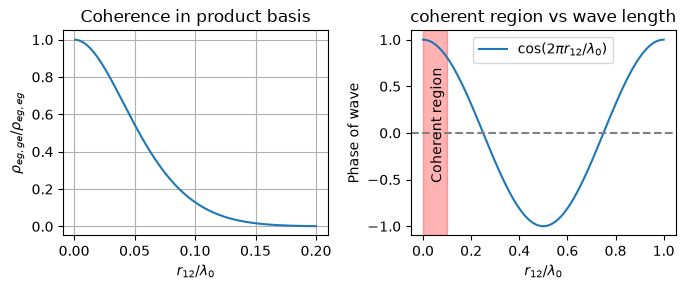

In [19]:
# calculate the off-diagonal element of steady state
x = []
y = []
times = np.linspace(0,100,200)
for k in range(1,201):
    r12=k/1000
    gamma12 = Gamma12(r12,theta)*gamma0
    H = system_hamiltonian(omega0,omega12)
    D = dissipator(omega0,gamma0,gamma12,temperature)
    L = liouvillian(H)+D
    psi0=tensor(basis(2,0),basis(2,0))
    result=mesolve(L,psi0,times)
    rho_ss = result.states[-1]
    x.append(r12)
    y.append(rho_ss[2,1].real/rho_ss[1,1].real)

# plot the results
plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
plt.title("Coherence in product basis")
plt.plot(x,y)
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel(r"$\rho_{eg,ge}/\rho_{eg,eg}$")
plt.grid(True)

plt.subplot(1,2,2)
plt.title("coherent region vs wave length")
x=np.linspace(0,1,100)
y=np.cos(2*np.pi*x)
plt.plot(x,y,label=r"$\cos(2\pi r_{12}/\lambda_{0})$")
plt.axhline(y=0,color='grey',ls='--')
plt.axvspan(0, 0.1, color='red', alpha=0.3)
plt.text(0.03, -0.5, "Coherent region", rotation="vertical", fontsize=10, color="k")
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel("Phase of wave")
plt.legend(loc=9)
plt.tight_layout() 
plt.show()

```{admonition}  Coherence distance
:class: note
:name: note:coherence_distance

The product basis kets $|eg\rangle$ and $|ge\rangle$ are coherent if the distance between two emitters is less than 10% of the wave length.
```